# Tutorial 1: Integrating adjacent DLPFC slices
This tutorial demonstrates STAligner's ablility to integrate multiple adjacent slices. The slices are sampled from human dorsolateral prefrontal cortex (DLPFC) and the processed data can be downloaded from https://drive.google.com/drive/folders/1pHJy2cB9BKqc3ny9IpvVhiw_8ukJMzPW?usp=share_link.

## Preparation

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import sys
import os

# Method 1: Add the STAligner-master directory to Python path
# This notebook is in Tutorials/, so parent directory is STAligner-master
staligner_root = r'E:\yan0\multi-sample-disentangle\baseline\STAligner-master\STAligner-master'
if os.path.exists(staligner_root) and staligner_root not in sys.path:
    sys.path.insert(0, staligner_root)

import STAligner

import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import scipy.sparse as sp
import scipy.linalg

import torch
used_device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

## Load Data

In [3]:
Batch_list = []
adj_list = []

In [4]:
adata = sc.read_h5ad('E:/yan0/multi-sample-disentangle/multi-sample-data/UTAG/infected_lung_adata.h5ad')

In [5]:
adata1 = adata[adata.obs['disease']=='Healthy']
adata2 = adata1[adata1.obs['roi'] == adata1.obs['roi'].unique()[21]]

adata2.var_names_make_unique(join="++")
adata2.obs['Ground Truth'] = adata2.obs['metacluster_label'].astype('category')

# make spot name unique
adata2.obs_names = [x+'_'+ '1' for x in adata2.obs_names]

# Constructing the spatial network
STAligner.Cal_Spatial_Net(adata2, rad_cutoff=20) # the spatial network are saved in adata.uns[‘adj’]

adj_list.append(adata2.uns['adj'])
Batch_list.append(adata2)

------Calculating spatial graph...
The graph contains 36144 edges, 7097 cells.
5.0929 neighbors per cell on average.


In [8]:
adata1 = adata[adata.obs['disease']=='Healthy']
adata2 = adata1[adata1.obs['roi'] == adata1.obs['roi'].unique()[-6]]

adata2.var_names_make_unique(join="++")
adata2.obs['Ground Truth'] = adata2.obs['metacluster_label'].astype('category')

# make spot name unique
adata2.obs_names = [x+'_'+ '2' for x in adata2.obs_names]

# Constructing the spatial network
STAligner.Cal_Spatial_Net(adata2, rad_cutoff=20) # the spatial network are saved in adata.uns[‘adj’]

adj_list.append(adata2.uns['adj'])
Batch_list.append(adata2)

------Calculating spatial graph...
The graph contains 19860 edges, 7199 cells.
2.7587 neighbors per cell on average.


In [6]:
adata1 = adata[adata.obs['disease'] == 'ARDS']
adata2 = adata1[adata1.obs['roi'] == adata1.obs['roi'].unique()[27]]

adata2.var_names_make_unique(join="++")
adata2.obs['Ground Truth'] = adata2.obs['metacluster_label'].astype('category')

# make spot name unique
adata2.obs_names = [x+'_'+ '3' for x in adata2.obs_names]

# Constructing the spatial network
STAligner.Cal_Spatial_Net(adata2, rad_cutoff=20) # the spatial network are saved in adata.uns[‘adj’]

adj_list.append(adata2.uns['adj'])
Batch_list.append(adata2)

------Calculating spatial graph...
The graph contains 36932 edges, 8817 cells.
4.1887 neighbors per cell on average.


In [7]:
adata1 = adata[adata.obs['disease'] == 'COVID19']
adata2 = adata1[adata1.obs['roi'] == adata1.obs['roi'].unique()[39]]

adata2.var_names_make_unique(join="++")
adata2.obs['Ground Truth'] = adata2.obs['metacluster_label'].astype('category')

# make spot name unique
adata2.obs_names = [x+'_'+ '4' for x in adata2.obs_names]

# Constructing the spatial network
STAligner.Cal_Spatial_Net(adata2, rad_cutoff=20) # the spatial network are saved in adata.uns[‘adj’]

adj_list.append(adata2.uns['adj'])
Batch_list.append(adata2)

------Calculating spatial graph...
The graph contains 10676 edges, 3797 cells.
2.8117 neighbors per cell on average.


In [8]:
section_ids = [str(i+1) for i in range(len(Batch_list))]

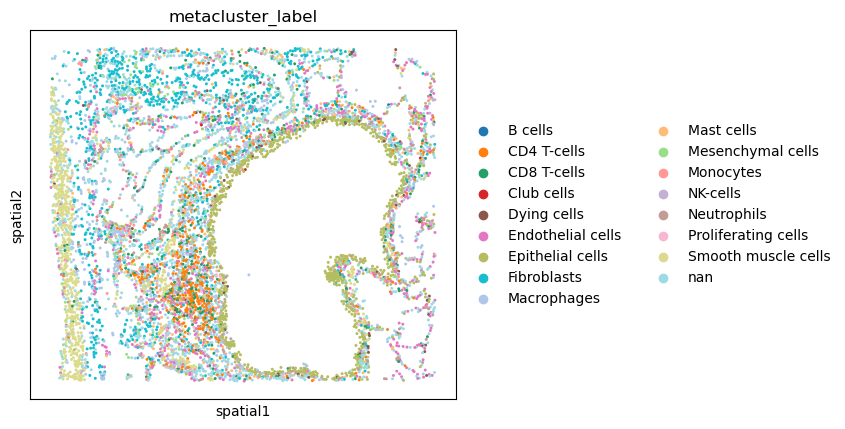

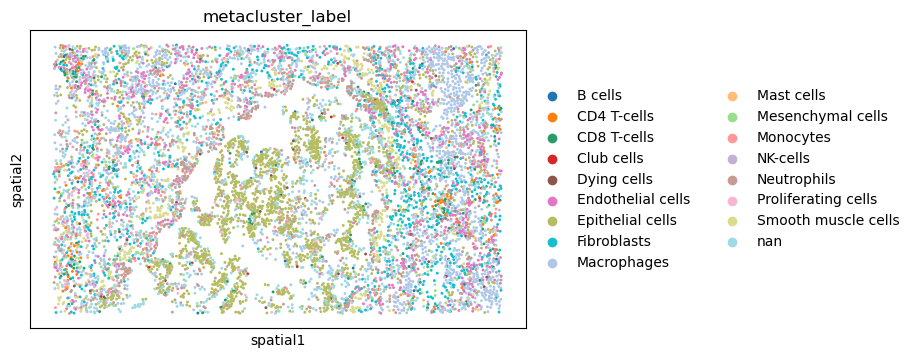

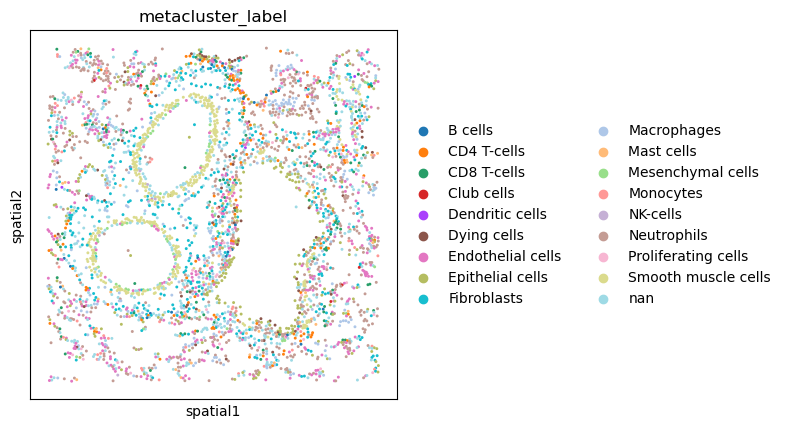

In [9]:
for adata in Batch_list:
    sc.pl.spatial(adata, img_key="hires", color=["metacluster_label"], spot_size=15, show=False)

## Concat the scanpy objects for multiple slices

In [10]:
Batch_list

[AnnData object with n_obs × n_vars = 7097 × 43
     obs: 'roi', 'sample', 'disease', 'phenotypes', 'acquisition_id', 'acquisition_date', 'obj_id', 'cluster_1.0', 'cluster_label', 'metacluster_label', 'X', 'Y', 'Ground Truth'
     uns: 'leiden', 'metacluster_label_colors', 'neighbors', 'pca', 'umap', 'Spatial_Net', 'adj'
     obsm: 'X_pca', 'X_umap', 'spatial'
     varm: 'PCs'
     obsp: 'connectivities', 'distances',
 AnnData object with n_obs × n_vars = 8817 × 43
     obs: 'roi', 'sample', 'disease', 'phenotypes', 'acquisition_id', 'acquisition_date', 'obj_id', 'cluster_1.0', 'cluster_label', 'metacluster_label', 'X', 'Y', 'Ground Truth'
     uns: 'leiden', 'metacluster_label_colors', 'neighbors', 'pca', 'umap', 'Spatial_Net', 'adj'
     obsm: 'X_pca', 'X_umap', 'spatial'
     varm: 'PCs'
     obsp: 'connectivities', 'distances',
 AnnData object with n_obs × n_vars = 3797 × 43
     obs: 'roi', 'sample', 'disease', 'phenotypes', 'acquisition_id', 'acquisition_date', 'obj_id', 'cluster

In [11]:
adata_concat = ad.concat(Batch_list, label="slice_name", keys=section_ids)
adata_concat.obs['Ground Truth'] = adata_concat.obs['Ground Truth'].astype('category')
adata_concat.obs["batch_name"] = adata_concat.obs["slice_name"].astype('category')
print('adata_concat.shape: ', adata_concat.shape)

adata_concat.shape:  (19711, 43)


## Concat the spatial network for multiple slices

In [12]:
adj_concat = np.asarray(adj_list[0].todense())
for batch_id in range(1,len(section_ids)):
    adj_concat = scipy.linalg.block_diag(adj_concat, np.asarray(adj_list[batch_id].todense()))
adata_concat.uns['edgeList'] = np.nonzero(adj_concat)

## Running STAligner

In [13]:
%%time
adata_concat = STAligner.train_STAligner(adata_concat, verbose=True, knn_neigh = 50, device=used_device)

STAligner(
  (conv1): GATConv(43, 512, heads=1)
  (conv2): GATConv(512, 30, heads=1)
  (conv3): GATConv(30, 512, heads=1)
  (conv4): GATConv(512, 43, heads=1)
)
Pretrain with STAGATE...


100%|██████████| 500/500 [00:17<00:00, 29.18it/s]


Train with STAligner...


  0%|          | 0/500 [00:00<?, ?it/s]

Update spot triplets at epoch 500


...

Update spot triplets at epoch 800


 80%|████████  | 400/500 [00:27<00:03, 27.34it/s]

Update spot triplets at epoch 900


100%|██████████| 500/500 [00:34<00:00, 14.37it/s]


CPU times: total: 59.1 s
Wall time: 52.6 s


In [14]:
adata_concat

AnnData object with n_obs × n_vars = 19711 × 43
    obs: 'roi', 'sample', 'disease', 'phenotypes', 'acquisition_id', 'acquisition_date', 'obj_id', 'cluster_1.0', 'cluster_label', 'metacluster_label', 'X', 'Y', 'Ground Truth', 'slice_name', 'batch_name'
    uns: 'edgeList'
    obsm: 'X_pca', 'X_umap', 'spatial', 'STAGATE', 'STAligner'

## Clustering

In [15]:
STAligner.mclust_R(adata_concat, num_cluster=6, used_obsm='STAligner')
adata_concat = adata_concat[adata_concat.obs['Ground Truth']!='unknown']

from sklearn.metrics import adjusted_rand_score as ari_score
print('mclust, ARI = %01.3f' % ari_score(adata_concat.obs['Ground Truth'], adata_concat.obs['mclust']))

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%
mclust, ARI = 0.128


## Visualization

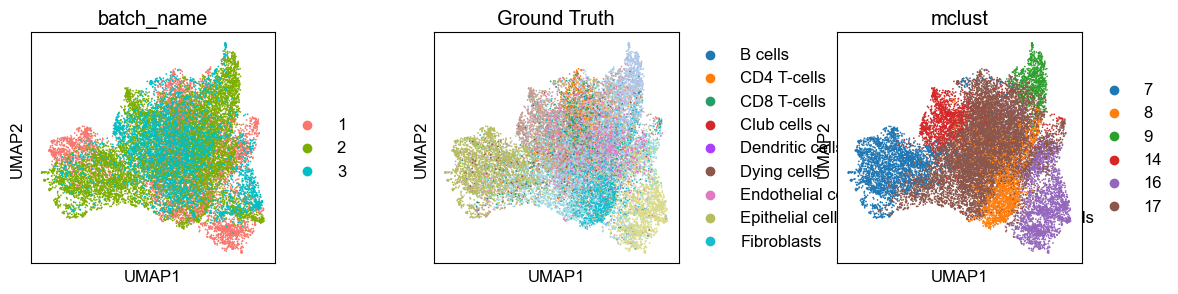

In [16]:
sc.pp.neighbors(adata_concat, use_rep='STAligner', random_state=666)
sc.tl.umap(adata_concat, random_state=666)

section_color = ['#f8766d', '#7cae00', '#00bfc4', '#c77cff']
section_color_dict = dict(zip(section_ids, section_color))
adata_concat.uns['batch_name_colors'] = [section_color_dict[x] for x in adata_concat.obs.batch_name.cat.categories]
adata_concat.obs['mclust'] = pd.Series(STAligner.match_cluster_labels(adata_concat.obs['Ground Truth'], adata_concat.obs['mclust'].values),
                                         index=adata_concat.obs.index, dtype='category')

import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = "Arial"
plt.rcParams["figure.figsize"] = (3, 3)
plt.rcParams['font.size'] = 12

sc.pl.umap(adata_concat, color=['batch_name', 'Ground Truth', 'mclust'], ncols=3, 
           wspace=0.5, show=True)

In [21]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score as ari_score

# 保存到 STAligner 文件夹（不是 Ours）
save_dir = r"E:/yan0/multi-sample-disentangle/results/lung_infected/STAligner/clustering"
os.makedirs(save_dir, exist_ok=True)

Batch_list1 = []
for section_id in section_ids:
    Batch_list1.append(adata_concat[adata_concat.obs["batch_name"] == section_id])

spot_size = 15
title_size = 12

# 计算每个样本 ARI
n_batches = len(Batch_list1)
ARI_list = []
for bb in range(n_batches):
    ARI_list.append(
        round(
            ari_score(
                Batch_list1[bb].obs["Ground Truth"],
                Batch_list1[bb].obs["mclust"],
            ),
            2,
        )
    )

# 分别保存每个 sample 的单图：无 legend + 黑边框
for bb in range(n_batches):
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    sc.pl.spatial(
        Batch_list1[bb],
        img_key=None,
        color=["mclust"],
        title=[""],
        legend_loc=None,   # 不显示 legend
        show=False,
        ax=ax,
        frameon=True,      # 开启边框
        spot_size=spot_size,
    )

    # ARI 标题
    # ax.set_title(f"ARI={ARI_list[bb]}", size=title_size)

    # 去坐标轴信息（如要保留可删）
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    # 黑色边框
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.5)

    out_path = os.path.join(save_dir, f"sample_{bb+1}_mclust.png")
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    print(f"Saved: {out_path}")

Saved: E:/yan0/multi-sample-disentangle/results/lung_infected/STAligner/clustering\sample_1_mclust.png
Saved: E:/yan0/multi-sample-disentangle/results/lung_infected/STAligner/clustering\sample_2_mclust.png
Saved: E:/yan0/multi-sample-disentangle/results/lung_infected/STAligner/clustering\sample_3_mclust.png


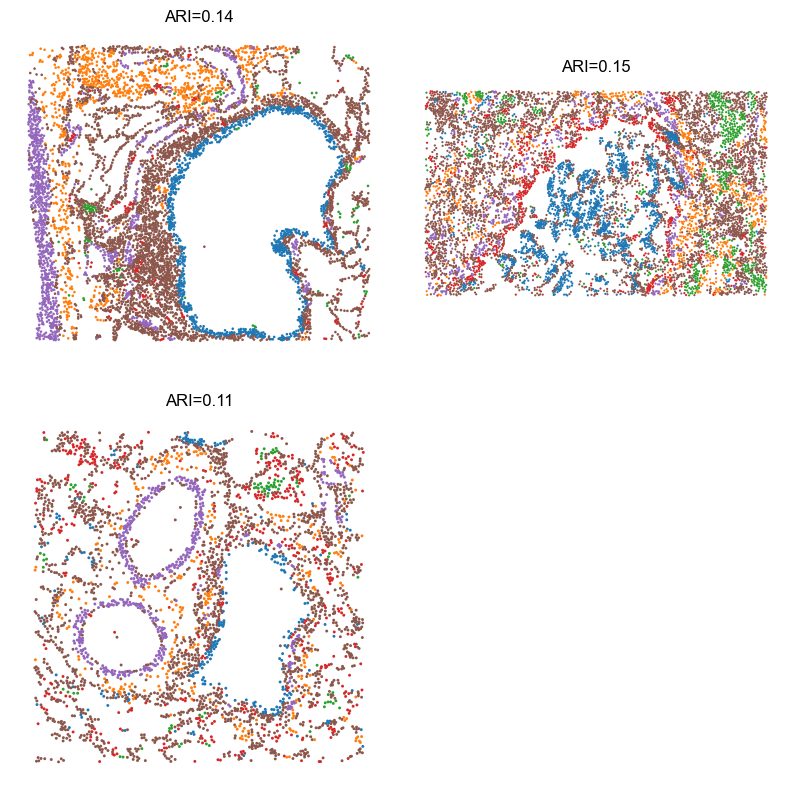

In [17]:
Batch_list1 = []
for section_id in section_ids:
    Batch_list1.append(adata_concat[adata_concat.obs['batch_name'] == section_id])
from sklearn.metrics import adjusted_rand_score as ari_score
import math

import matplotlib.pyplot as plt
spot_size = 15
title_size = 12

# 根据实际数量计算ARI
n_batches = len(Batch_list1)
ARI_list = []
for bb in range(n_batches):
    ARI_list.append(round(ari_score(Batch_list1[bb].obs['Ground Truth'], Batch_list1[bb].obs['mclust']), 2))

# 计算子图布局：固定2列，行数根据数量计算
n_cols = 2
n_rows = math.ceil(n_batches / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows), gridspec_kw={'wspace': 0.05, 'hspace': 0.1})

# 确保axes是二维数组
if n_rows == 1:
    axes = axes.reshape(1, -1)
elif n_cols == 1:
    axes = axes.reshape(-1, 1)

# 绘制每个batch
for bb in range(n_batches):
    row = bb // n_cols
    col = bb % n_cols
    ax = axes[row, col]
    
    _sc = sc.pl.spatial(Batch_list1[bb], img_key=None, color=['mclust'], title=[''],
                        legend_loc=None, legend_fontsize=12, show=False, ax=ax, frameon=False,
                        spot_size=spot_size)
    _sc[0].set_title("ARI=" + str(ARI_list[bb]), size=title_size)

# 隐藏多余的子图
for bb in range(n_batches, n_rows * n_cols):
    row = bb // n_cols
    col = bb % n_cols
    axes[row, col].axis('off')

In [25]:
import os
import numpy as np
import pandas as pd
from sklearn.metrics import adjusted_rand_score as ari_score

# ========= 1) 重新计算每个样本 ARI（不做提前四舍五入） =========
Batch_list1 = [adata_concat[adata_concat.obs["batch_name"] == sid] for sid in section_ids]

ari_values = []
for ad in Batch_list1:
    y_true = ad.obs["Ground Truth"]
    y_pred = ad.obs["mclust"]
    ari_values.append(float(ari_score(y_true, y_pred)))

# ========= 2) 保存到 ari.csv（小数点后 6 位） =========
method_name = "STAligner"
metrics_dir = r"E:\yan0\multi-sample-disentangle\results\lung_infected\metrics"
os.makedirs(metrics_dir, exist_ok=True)
csv_path = os.path.join(metrics_dir, "ari.csv")

# 固定3个样本列，不足补 NaN，超出只取前3个
vals = ari_values[:3] + [np.nan] * max(0, 3 - len(ari_values))

new_row = pd.DataFrame([{
    "method": method_name,
    "sample1_ari": vals[0],
    "sample2_ari": vals[1],
    "sample3_ari": vals[2],
}])

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    if "method" in df.columns and (df["method"] == method_name).any():
        df.loc[df["method"] == method_name, ["sample1_ari", "sample2_ari", "sample3_ari"]] = vals
    else:
        df = pd.concat([df, new_row], ignore_index=True)
else:
    df = new_row

df.to_csv(csv_path, index=False, encoding="utf-8-sig", float_format="%.6f")

print("Recomputed ARI:", [f"{x:.6f}" for x in ari_values])
print("Saved:", csv_path)

Recomputed ARI: ['0.137995', '0.146806', '0.113410']
Saved: E:\yan0\multi-sample-disentangle\results\lung_infected\metrics\ari.csv
